 # Target and Class Imbalance 

Looking at the 835 patients with 32 variables, after cleaned by:

- Dropped columns: "STDs: cervical condylomatosis", "STDs: AIDS" because of 0 variance and a constant 0 value, and "STDS: Time since first/last diagnosis" with 91.7% missing data 

- Created "feature_missing" columns for each with a significant amount of missing data, like variables "Smokes", "Hormonal Contraceptives", "IUD", and "STDs", before filling with 0s to include both in our analysis

- Filled variables "Number of sexual partners", "First sexual intercourse", "Number of pregnancies" with median since genuinely unknown 

- Removed 23 duplicates, losing one positive test result on Schiller, Citology, and Biopsy result

## Setup + Import Clean Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

figures = Path("../04_FIGURES")
results = Path("../05_RESULTS")
data = Path("../01_DATA/test_train_split")
figures.mkdir(parents=True, exist_ok=True)
results.mkdir(parents=True, exist_ok=True)
data.mkdir(parents=True, exist_ok=True)

clean_data = Path("../01_DATA/processed/cervical_cancer_final.csv")

train_path = data / "X_train.csv"
train_resample_path = data / "X_train_resampled.csv"
test_path = data / "X_test.csv"

class_imbalance_fig_path = figures / "class_imbalance.png"

df = pd.read_csv(clean_data)
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,Schiller,Citology,Biopsy,smokes_missing,hormonal_contraceptives_missing,iud_missing,stds_missing,number_of_sexual_partners_missing,first_sexual_intercourse_missing,num_of_pregnancies_missing
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0,0,0,0,0,0,0,0,0,0


## Target Selection
The selected target of interest is Biopsy, as it is histological. 0 = negative, 1 = positive. The model will be trained to predict this outcome from the other remaining variables. First, will check if every positive Biopsy result has at least one other positive diagnostic test (Hinselmann, Schiller, or Citology) to confirm the removal of these columns to avoid leakage for feature selection as these diagnostic tests would predict a postive Biopsy result much more frequently than the risk factors alone- our main question to answer. 

In [64]:
biopsy_pos = df[df["Biopsy"] == 1]

diagnostic_pos = (
    (biopsy_pos["Hinselmann"] == 1) | 
    (biopsy_pos["Schiller"] == 1) |
    (biopsy_pos["Citology"] == 1))

print(f"Number of positive biopsies: {len(biopsy_pos)}")
print(f"Number of positive biopsies with at least one positive diagnostic test: {diagnostic_pos.sum()}")
print(f"Fraction covered: {diagnostic_pos.mean():.2f}")

Number of positive biopsies: 54
Number of positive biopsies with at least one positive diagnostic test: 48
Fraction covered: 0.89


Because the majority, or 89%, of the positive biopsy results have at least one positive diagnostic test result, these 3 columns ("Hinselmann", "Schiller", and "Citology") will be dropped in one dataset for feature selection as it would skew accurate prediction from risk factors. We will also do analysis with these diagnostic columns included to show their influence and prediction power. 

In [65]:
y = df["Biopsy"]

no_diag_df = df.drop(columns=["Biopsy", "Hinselmann", "Schiller", "Citology"])
print(f"DF shape with no diagnostics: {no_diag_df.shape}")

diag_df = df.drop(columns= ["Biopsy"])
print(f"DF shape with diagnostics: {diag_df.shape}")

DF shape with no diagnostics: (835, 35)
DF shape with diagnostics: (835, 38)


## Class Imbalance Handling
All four tests (Hinselmann, Schiller, Citology, and Biopsy) have under 10% positive results. Since we are mainly focusing on Biopsy as our variable of interest, we will only handle this imbalance where the others will be considered features. The first analysis will be using the first feature set, excluding the diagnostic tests, followed by the second feature set including the diagnostic tests. 

In [66]:
# Checking the imbalance 
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Biopsy
0    781
1     54
Name: count, dtype: int64
Biopsy
0    0.935
1    0.065
Name: proportion, dtype: float64


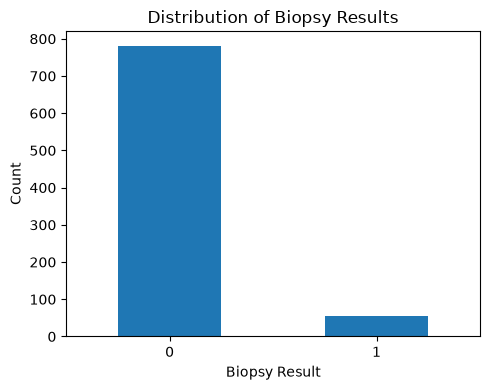

In [67]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().plot(kind="bar", ax=ax, rot=0)
ax.set_title("Distribution of Biopsy Results")
ax.set_xlabel("Biopsy Result")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(class_imbalance_fig_path, dpi=150, bbox_inches="tight")
plt.show() 

Only 54 or about 6.5% of biopsies were positive, indicating a major class imbalance. To adjust, we will be comparing class weighting and SMOTE methods to determine which is more effective for balancing this data for further analysis. Before starting these methods, I will create train/test splits in the data. 

In [68]:
x_train, x_test, y_train, y_test = train_test_split(no_diag_df, y, test_size=0.3, stratify=y, random_state=42)

print("train:", y_train.value_counts().to_dict())
print("test:", y_test.value_counts().to_dict())

train: {0: 546, 1: 38}
test: {0: 235, 1: 16}


## Class Weighting (Training Set Only)

In [69]:
from sklearn.linear_model import LogisticRegression 

weighted_model = LogisticRegression (class_weight="balanced", max_iter=5000)
weighted_model.fit(x_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

## SMOTE (Training Set Only)

In [70]:
smote = SMOTE(random_state=42)
x_train_resamp, y_train_resamp = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_resamp.value_counts().to_dict())

Before SMOTE: {0: 546, 1: 38}
After SMOTE: {0: 546, 1: 546}


SMOTE applied correctly: leveled out 0 and 1 results to make them 1:1, or 546:546, evening out the data amount balance. Now to save the training datasets into shared folders for reproducibility. 

In [71]:
x_train.assign(Biopsy=y_train).to_csv(train_path, index=False)
x_train_resamp.assign(Biopsy=y_train_resamp).to_csv(train_resample_path, index=False)
x_test.assign(Biopsy=y_test).to_csv(test_path, index=False)

## Comparing Class Weighting and SMOTE for Class Imbalance 

To determine which method (class weight or SMOTE) helped to balance the data, we will use the same 10-fold cross-validation on the training set, using a 'imblearn' pipeline for SMOTE to refit each fold on the training portion only. 

In [78]:
from sklearn.model_selection import cross_val_score, StratifiedKFold 
from imblearn.pipeline import Pipeline 

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

weighted_score = cross_val_score(weighted_model, x_train, y_train, cv=cv, scoring="average_precision")

smote_pipe = Pipeline([("smote", smote), ("clf", LogisticRegression(max_iter=5000))])
smote_score = cross_val_score(smote_pipe, x_train, y_train, cv=cv, scoring="average_precision")

print(f"Class Weighting: PR-AUC = {weighted_score.mean():.2f} +/- {weighted_score.std():.2f}")
print(f"SMOTE: PR-AUC = {smote_score.mean():.2f} +/- {smote_score.std():.2f}")

Class Weighting: PR-AUC = 0.15 +/- 0.09
SMOTE: PR-AUC = 0.12 +/- 0.08


PR-AUC was used to compare methods as precision and recall can better determine how well the model predicts versus accuracy, as guessing in the dataset could still lead to a high accuracy with the small minority of positive biopsy results. With the slightly higher PR-AUC in class weighting, potentially due to the data noise created in SMOTE, we will proceed using the class weighting method for class imbalance. As the PR-AUC is still low for this model, we will proceed to feature selection in the next step to identify which variables contribute to the best model prediction. 

## Class Weighting for Dataset with Diagnostic Tests (Training Set Only)


In [73]:
diag_x_train, diag_x_test, diag_y_train, diag_y_test = train_test_split(diag_df, y, test_size=0.3, stratify=y, random_state=42)

print("train:", diag_y_train.value_counts().to_dict())
print("test:", diag_y_test.value_counts().to_dict())

train: {0: 546, 1: 38}
test: {0: 235, 1: 16}


In [74]:
diag_weighted_model = LogisticRegression (class_weight="balanced", max_iter=5000)
diag_weighted_model.fit(diag_x_train, diag_y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [75]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
diag_weighted_score = cross_val_score(diag_weighted_model, diag_x_train, diag_y_train, cv=cv, scoring="average_precision")
print(f"Class Weighting for Dataset with Diagnostics: PR-AUC = {diag_weighted_score.mean():.2f} +/- {diag_weighted_score.std():.2f}")

Class Weighting for Dataset with Diagnostics: PR-AUC = 0.72 +/- 0.16


The PR-AUC is noticeably much higher with the diagnostic tests included without feature selection, which was expected. 

In [76]:
diag_train_path = data / "Diag_X_train.csv"
diag_test_path = data / "Diag_X_test.csv"

diag_x_train.assign(Biopsy=diag_y_train).to_csv(diag_train_path, index=False)
diag_x_test.assign(Biopsy=diag_y_test).to_csv(diag_test_path, index=False)

To save train/test data globally for dataset with diagnostic tests. 